# Stock Price Prediction Analysis

This notebook demonstrates the complete workflow for stock price prediction using LSTM and GRU neural networks.

## Table of Contents
1. [Setup and Imports](#Setup-and-Imports)
2. [Data Loading and Exploration](#Data-Loading-and-Exploration)
3. [Data Preprocessing](#Data-Preprocessing)
4. [Model Building](#Model-Building)
5. [Training](#Training)
6. [Evaluation](#Evaluation)
7. [Comparison](#Comparison)

## Setup and Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')


## Data Loading and Exploration

In [4]:
# Adani Ports ticker symbol on NSE (National Stock Exchange of India)
ticker = "ADANIPORTS.NS"

# Define date range
start_date = "2021-03-28"
end_date = "2026-03-28"  # Note: Will only return data up to today

# Download the data
df = yf.download(ticker, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [5]:
# Flatten MultiIndex columns to single level
df.columns = ['_'.join(col).strip() for col in df.columns.values]
df.reset_index(inplace=True)

In [6]:
# Rename columns for easier access
df.rename(columns={
    'Close_ADANIPORTS.NS': 'Close',
    'Open_ADANIPORTS.NS': 'Open', 
    'High_ADANIPORTS.NS': 'High',
    'Low_ADANIPORTS.NS': 'Low',
    'Volume_ADANIPORTS.NS': 'Volume'
}, inplace=True)

In [7]:
# Basic statistics
df.describe()

,Date,Close,High,Low,Open,Volume
count,1236,1236.000000,1236.000000,1236.000000,1236.000000,1.236000e+03
mean,2023-09-27 18:23:18,1017.986081,1033.057942,1004.147551,1019.900044,6.444519e+06
min,2021-03-30 00:00:00,455.184814,499.034926,388.892904,451.789016,0.000000e+00
25%,2022-06-27 18:00:00,727.237991,736.853042,718.605363,728.197692,2.258730e+06
50%,2023-09-25 12:00:00,858.989716,874.246198,845.399029,859.038928,3.710298e+06
75%,2024-12-30 06:00:00,1354.515778,1372.454487,1334.044864,1354.151770,6.655277e+06
max,2026-03-27 00:00:00,1582.451172,1606.656410,1560.905968,1575.900024,1.155175e+08
std,NaN,316.754663,318.869137,314.626066,317.169818,9.400372e+06


In [8]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values!")

Missing values per column:
No missing values!


In [9]:
pd.DataFrame({"missing_value":df.isna().sum(),"Data_type":df.dtypes})

,missing_value,Data_type
Date,0,datetime64[s]
Close,0,float64
High,0,float64
Low,0,float64
Open,0,float64
Volume,0,int64


In [10]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [11]:
# # df[['Date', 'Close', 'High', 'Low', 'Open', 'Volume']].astype(float)

# def convert_volume(val):
#     if isinstance(val, str):
#         # Remove any commas first
#         val = val.replace(',', '')
        
#         # Check for Million suffix
#         if 'M' in val:
#             return float(val.replace('M', '')) * 1_000_000
#         # Check for Thousand suffix
#         elif 'K' in val:
#             return float(val.replace('K', '')) * 1_000
#         # Just a number
#         else:
#             return float(val)
#     return val

# df['Vol.'] = df['Vol.'].apply(convert_volume)

In [12]:
# columns_convert=['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
# for col in columns_convert:
#     df[col]=df[col].str.replace(",","").astype(float)

In [13]:
df.to_csv(r"../data/Adani_port_stock.csv",sep=",")

In [17]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2021-03-30,689.743225,696.975081,676.881220,682.462845,9109273
1,2021-03-31,681.831909,698.819463,678.143136,684.355751,7752226
2,2021-04-01,714.690674,720.272299,684.355756,692.606853,15017049
3,2021-04-05,720.514954,723.184426,694.062906,710.322421,15622924
4,2021-04-06,811.082886,827.730712,721.243005,733.862331,64555516


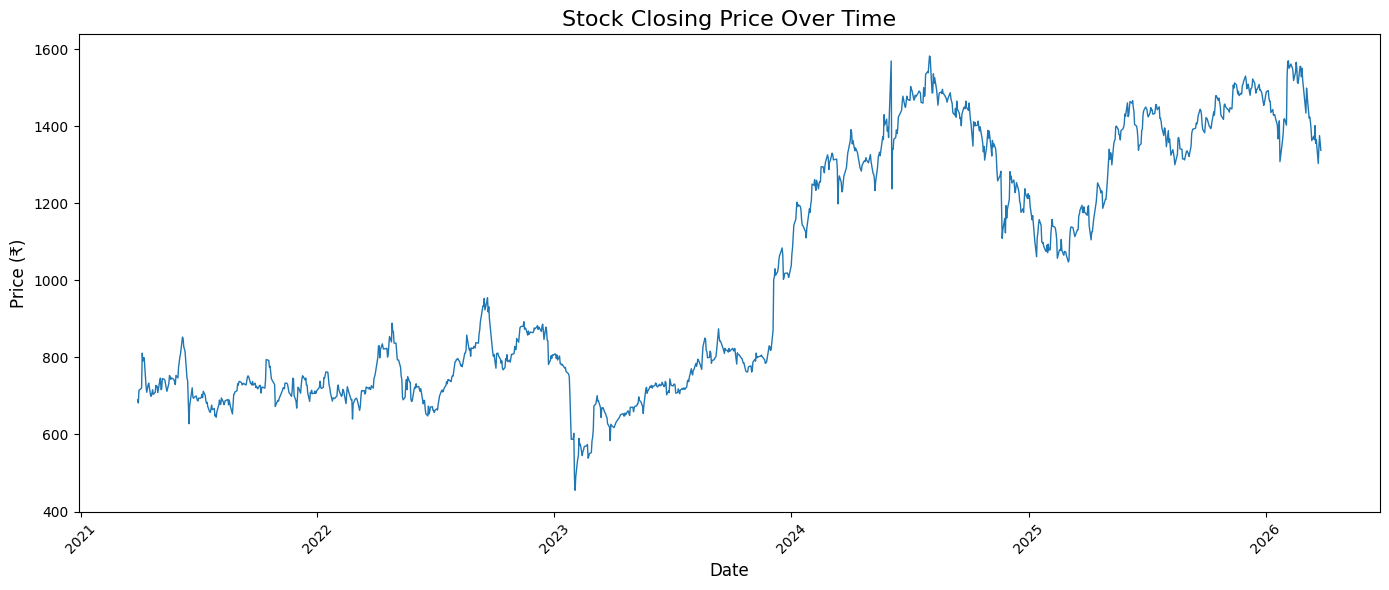

In [14]:
# Plot closing price over time
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], linewidth=1)
plt.title('Stock Closing Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (₹)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(False)
plt.tight_layout()
plt.show()

In [15]:
len(df)

1236

In [23]:
sequences = []
targets = []
    
for i in range(len(df) - 3):
    sequences.append(df.iloc[i:i + 3])
    targets.append(df.iloc[i + 3])
    

In [22]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2021-03-30,689.743225,696.975081,676.881220,682.462845,9109273
1,2021-03-31,681.831909,698.819463,678.143136,684.355751,7752226
2,2021-04-01,714.690674,720.272299,684.355756,692.606853,15017049
3,2021-04-05,720.514954,723.184426,694.062906,710.322421,15622924
4,2021-04-06,811.082886,827.730712,721.243005,733.862331,64555516


In [24]:
sequences

[        Date       Close        High         Low        Open    Volume
 0 2021-03-30  689.743225  696.975081  676.881220  682.462845   9109273
 1 2021-03-31  681.831909  698.819463  678.143136  684.355751   7752226
 2 2021-04-01  714.690674  720.272299  684.355756  692.606853  15017049,
         Date       Close        High         Low        Open    Volume
 1 2021-03-31  681.831909  698.819463  678.143136  684.355751   7752226
 2 2021-04-01  714.690674  720.272299  684.355756  692.606853  15017049
 3 2021-04-05  720.514954  723.184426  694.062906  710.322421  15622924,
         Date       Close        High         Low        Open    Volume
 2 2021-04-01  714.690674  720.272299  684.355756  692.606853  15017049
 3 2021-04-05  720.514954  723.184426  694.062906  710.322421  15622924
 4 2021-04-06  811.082886  827.730712  721.243005  733.862331  64555516,
         Date       Close        High         Low        Open    Volume
 3 2021-04-05  720.514954  723.184426  694.062906  710.322421

In [25]:
targets

[Date      2021-04-05 00:00:00
 Close              720.514954
 High               723.184426
 Low                694.062906
 Open               710.322421
 Volume               15622924
 Name: 3, dtype: object,
 Date      2021-04-06 00:00:00
 Close              811.082886
 High               827.730712
 Low                721.243005
 Open               733.862331
 Volume               64555516
 Name: 4, dtype: object,
 Date      2021-04-07 00:00:00
 Close              790.891968
 High               859.084862
 Low                  771.7203
 Open               831.904776
 Volume               97717880
 Name: 5, dtype: object,
 Date      2021-04-08 00:00:00
 Close              798.900452
 High               813.461213
 Low                782.398255
 Open               794.046864
 Volume               34025873
 Name: 6, dtype: object,
 Date      2021-04-09 00:00:00
 Close              799.482849
 High               812.490486
 Low                793.124662
 Open               800.599198
 

## Data Preprocessing

In [ ]:
# Import preprocessing functions
import sys
sys.path.append('../src')
from data_preprocessing import prepare_data, clean_data

In [ ]:
# Clean data
df_clean = clean_data(df)

# Prepare data for training
SEQUENCE_LENGTH = 60
TRAIN_RATIO = 0.8

data = prepare_data(
    df_clean,
    target_column='Close',
    sequence_length=SEQUENCE_LENGTH,
    train_ratio=TRAIN_RATIO
)

X_train, y_train = data['X_train'], data['y_train']
X_test, y_test = data['X_test'], data['y_test']
scaler = data['scaler']

print(f"Training samples: {X_train.shape}")
print(f"Test samples: {X_test.shape}")

## Model Building

In [ ]:
# Import model functions
from model_lstm import create_lstm_model
from model_gru import create_gru_model

In [ ]:
# Create LSTM model
INPUT_SHAPE = (SEQUENCE_LENGTH, 1)

lstm_model = create_lstm_model(
    input_shape=INPUT_SHAPE,
    lstm_units=[50, 50],
    dropout_rate=0.2
)

print("LSTM Model Summary:")
lstm_model.summary()

In [ ]:
# Create GRU model
gru_model = create_gru_model(
    input_shape=INPUT_SHAPE,
    gru_units=[50, 50],
    dropout_rate=0.2
)

print("GRU Model Summary:")
gru_model.summary()

## Training

In [ ]:
# Training parameters
EPOCHS = 50
BATCH_SIZE = 32
PATIENCE = 10

In [ ]:
# Train LSTM model
from model_lstm import train_lstm_model

print("Training LSTM Model...")
lstm_history = train_lstm_model(
    model=lstm_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_test,
    y_val=y_test,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE,
    verbose=1
)

In [ ]:
# Train GRU model
from model_gru import train_gru_model

print("Training GRU Model...")
gru_history = train_gru_model(
    model=gru_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_test,
    y_val=y_test,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE,
    verbose=1
)

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(lstm_history.history['loss'], label='LSTM Train Loss')
axes[0].plot(lstm_history.history['val_loss'], label='LSTM Val Loss')
axes[0].plot(gru_history.history['loss'], label='GRU Train Loss')
axes[0].plot(gru_history.history['val_loss'], label='GRU Val Loss')
axes[0].set_title('Model Loss During Training')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE plot
axes[1].plot(lstm_history.history['mae'], label='LSTM Train MAE')
axes[1].plot(lstm_history.history['val_mae'], label='LSTM Val MAE')
axes[1].plot(gru_history.history['mae'], label='GRU Train MAE')
axes[1].plot(gru_history.history['val_mae'], label='GRU Val MAE')
axes[1].set_title('Model MAE During Training')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluation

In [ ]:
# Evaluate LSTM model
from model_lstm import evaluate_lstm_model
from model_gru import evaluate_gru_model

lstm_results = evaluate_lstm_model(lstm_model, X_test, y_test, scaler)
gru_results = evaluate_gru_model(gru_model, X_test, y_test, scaler)

print("=" * 50)
print("LSTM Model Evaluation:")
print(f"  RMSE: ${lstm_results['rmse']:.4f}")
print(f"  MAE:  ${lstm_results['mae']:.4f}")
print(f"  R²:   {lstm_results['r2']:.4f}")

print("\n" + "=" * 50)
print("GRU Model Evaluation:")
print(f"  RMSE: ${gru_results['rmse']:.4f}")
print(f"  MAE:  ${gru_results['mae']:.4f}")
print(f"  R²:   {gru_results['r2']:.4f}")

In [ ]:
# Plot predictions vs actual
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# LSTM predictions
axes[0].plot(lstm_results['actual'], label='Actual Price', linewidth=2)
axes[0].plot(lstm_results['predictions'], label='LSTM Prediction', linewidth=2, alpha=0.8)
axes[0].set_title('LSTM Model: Actual vs Predicted Stock Price', fontsize=14)
axes[0].set_xlabel('Time Steps')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# GRU predictions
axes[1].plot(gru_results['actual'], label='Actual Price', linewidth=2)
axes[1].plot(gru_results['predictions'], label='GRU Prediction', linewidth=2, alpha=0.8)
axes[1].set_title('GRU Model: Actual vs Predicted Stock Price', fontsize=14)
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Price ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison

In [ ]:
# Compare metrics side by side
metrics = ['RMSE', 'MAE', 'R²']
lstm_values = [lstm_results['rmse'], lstm_results['mae'], lstm_results['r2']]
gru_values = [gru_results['rmse'], gru_results['mae'], gru_results['r2']]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, lstm_values[:2], width, label='LSTM', color='steelblue')
bars2 = ax.bar(x + width/2, gru_values[:2], width, label='GRU', color='coral')

ax.set_ylabel('Value')
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['RMSE ($)', 'MAE ($)'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
# R² comparison
fig, ax = plt.subplots(figsize=(8, 6))
models = ['LSTM', 'GRU']
r2_scores = [lstm_results['r2'], gru_results['r2']]
colors = ['steelblue', 'coral']

bars = ax.bar(models, r2_scores, color=colors)
ax.set_ylabel('R² Score')
ax.set_title('R² Score Comparison (Higher is Better)', fontsize=14)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated:
1. **Data Loading**: Loaded historical stock price data
2. **Preprocessing**: Cleaned and normalized data, created sequences
3. **Model Building**: Created LSTM and GRU architectures
4. **Training**: Trained both models with early stopping
5. **Evaluation**: Compared model performance using RMSE, MAE, and R²

### Key Findings:
- Both LSTM and GRU models can effectively predict stock prices
- The model with higher R² and lower RMSE/MAE performs better
- Early stopping prevents overfitting

### Next Steps:
- Try different hyperparameters (sequence length, layers, units)
- Add more features (volume, technical indicators)
- Implement ensemble methods